正在读取样本 49...
正在读取样本 50...
正在读取样本 51...
正在读取样本 52...
正在读取样本 53...
正在读取样本 54...


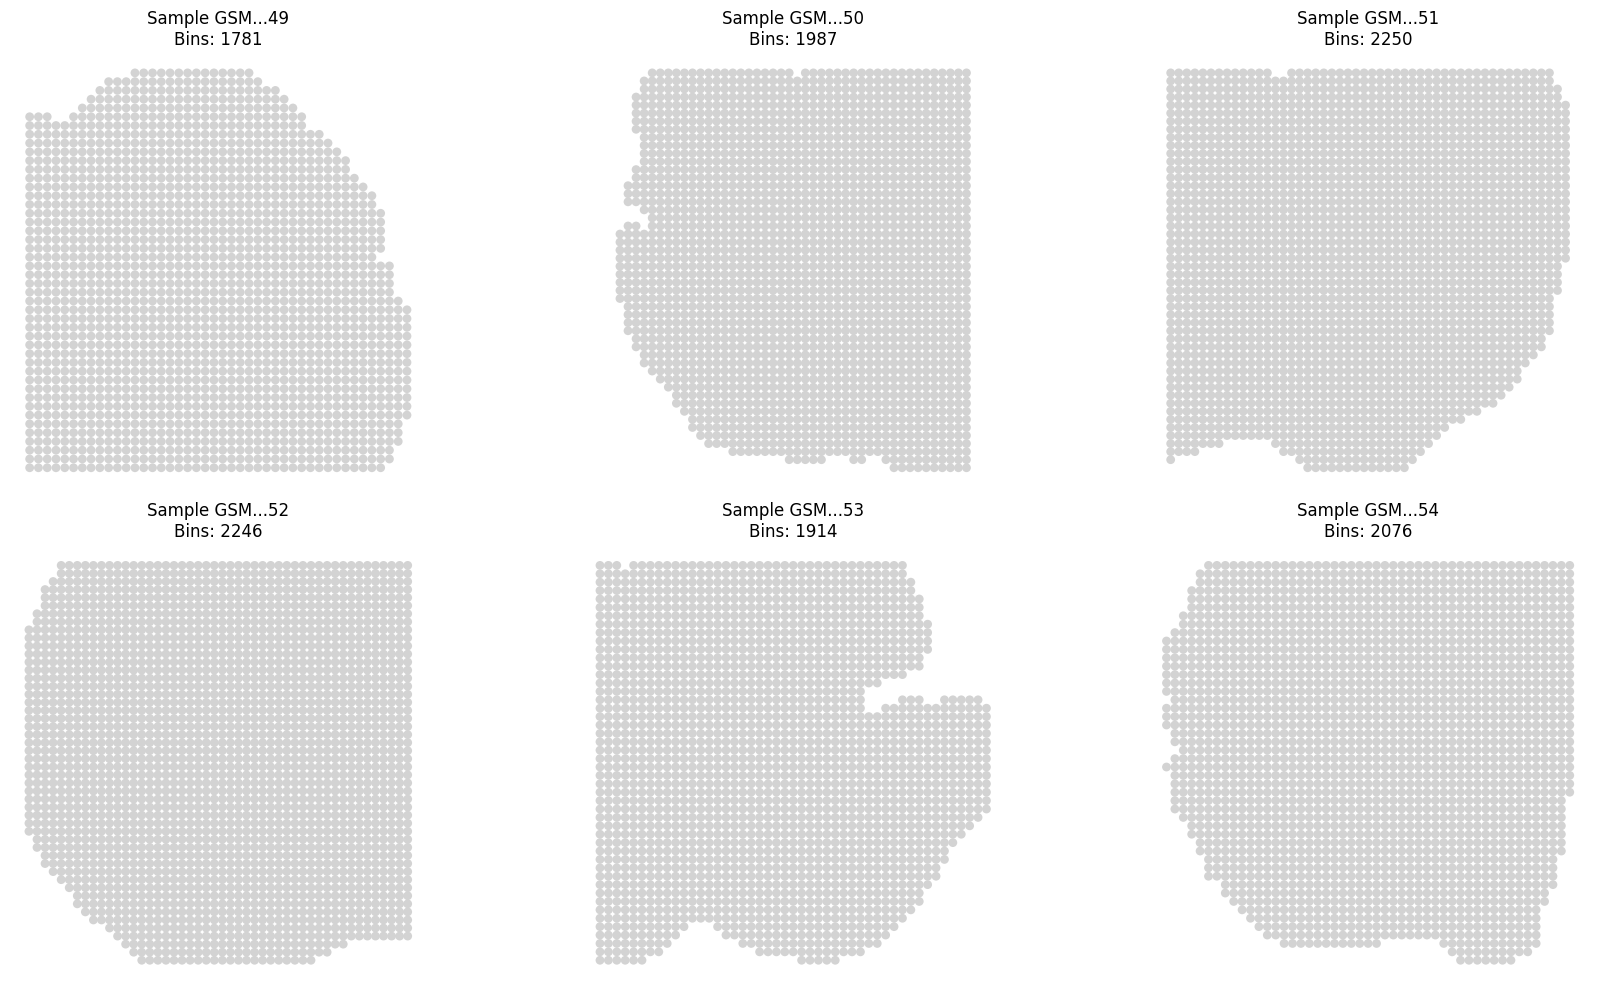

In [14]:
import scanpy as sc
import matplotlib.pyplot as plt
import os
import numpy as np

# 1. 设置路径模板
base_path = r"C:\Users\28616\Desktop\spatialDE_rawdata"
ids = range(49, 55) # 49 到 54

# 2. 准备画布 (2行3列)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, file_id in enumerate(ids):
    # 构建完整路径
    file_name = f"GSM81924{file_id}_GeneID_tissue.h5ad"
    full_path = os.path.join(base_path, file_name)
    
    if not os.path.exists(full_path):
        print(f"❌ 文件不存在: {full_path}")
        continue
        
    # 读取数据
    print(f"正在读取样本 {file_id}...")
    adata_raw = sc.read_h5ad(full_path)
    
    # 3. 提取坐标
    # 注意：请根据你数据的实际列名修改 'x' 和 'y'
    # 如果不确定，可以先打印 print(adata_raw.obs.columns) 查看
    try:
        if 'x' in adata_raw.obs.columns and 'y' in adata_raw.obs.columns:
            x = adata_raw.obs['x']
            y = adata_raw.obs['y']
        elif 'spatial_x' in adata_raw.obs.columns:
            x = adata_raw.obs['spatial_x']
            y = adata_raw.obs['spatial_y']
        else:
            # 如果在 obs 里找不到，尝试去 obsm 里找
            x = adata_raw.obsm['spatial'][:, 0]
            y = adata_raw.obsm['spatial'][:, 1]
            
        # 4. 绘图
        ax = axes[i]
        # s 是点的大小，可以根据 bin 的密度调整
        ax.scatter(x, y, s=40, c='lightgrey', edgecolors='none') 
        
        ax.set_title(f"Sample GSM...{file_id}\nBins: {len(adata_raw)}", fontsize=12)
        ax.set_aspect('equal') # 保持坐标比例，防止切片变形
        ax.axis('off') # 关闭坐标轴显示，只看切片形状
        
    except Exception as e:
        print(f"绘制样本 {file_id} 时出错: {e}")

plt.tight_layout()

# 保存原始切片图到桌面
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")
plt.savefig(os.path.join(desktop_path, "original_slices_view.png"), dpi=300)

plt.show()

In [15]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import gc
from scipy.sparse import issparse

# --- 1. 路径与参数配置 ---
data_raw_dir = r"C:\Users\28616\Desktop\spatialDE_rawdata\ATOI"
list_dir = r"C:\Users\28616\Desktop\spCLUE_Results"
output_dir = r"C:\Users\28616\Desktop\Cluster_Matrices"
if not os.path.exists(output_dir): os.makedirs(output_dir)

samples = ["49", "50", "51", "52", "53", "54"]
target_clusters = list(range(6)) # 0-5
layer_key = 'AGcount_A'

# --- 2. 预扫描：确定全局位点并集 (保证所有 Cluster 维度一致，方便后续横向对比) ---
print("🔍 正在同步全局位点...")
all_sites_set = set()
for s in samples:
    path = os.path.join(data_raw_dir, f"GSM81924{s}_AtoI_tissue.h5ad")
    if os.path.exists(path):
        try:
            temp = sc.read_h5ad(path, backed='r')
            all_sites_set.update(temp.var_names)
        except: continue

site_list = sorted(list(all_sites_set))
site_to_idx = {site: i for i, site in enumerate(site_list)}
n_total_sites = len(site_list)

# --- 3. 循环每一个 Cluster，生成独立矩阵 ---
for c in target_clusters:
    print(f"📂 正在构建 Cluster {c} 的独立矩阵...")
    cluster_rows = []
    cluster_labels = []
    
    for s in samples:
        h5ad_path = os.path.join(data_raw_dir, f"GSM81924{s}_AtoI_tissue.h5ad")
        
        # 初始化当前样本在该 Cluster 的向量
        vec_G = np.zeros(n_total_sites)
        vec_A = np.zeros(n_total_sites)
        
        if os.path.exists(h5ad_path):
            try:
                adata = sc.read_h5ad(h5ad_path)
                current_map = [site_to_idx[g] for g in adata.var_names]
                
                txt_path = os.path.join(list_dir, f"{s}_cluster{c}.txt")
                if os.path.exists(txt_path):
                    with open(txt_path, 'r') as f:
                        target_ids = [line.strip() for line in f if line.strip()]
                    
                    sub = adata[adata.obs_names.isin(target_ids)]
                    if sub.n_obs > 0:
                        # 提取 G
                        sum_G = sub.X.sum(axis=0)
                        vec_G[current_map] = np.array(sum_G).flatten() if issparse(sum_G) else np.ravel(sum_G)
                        # 提取 A
                        if layer_key in sub.layers:
                            sum_A = sub.layers[layer_key].sum(axis=0)
                            vec_A[current_map] = np.array(sum_A).flatten() if issparse(sum_A) else np.ravel(sum_A)
                del adata
                gc.collect()
            except:
                print(f"  ⚠️ 样本 {s} 读取失败，该行将填充为 0")

        # 按照 49_G, 49_A 的顺序加入
        cluster_rows.append(vec_G)
        cluster_labels.append(f"{s}_G")
        cluster_rows.append(vec_A)
        cluster_labels.append(f"{s}_A")

    # 保存当前 Cluster 的 12 x N 矩阵
    df_cluster = pd.DataFrame(np.vstack(cluster_rows), index=cluster_labels, columns=site_list)
    save_path = os.path.join(output_dir, f"Cluster_{c}_matrix_12xn.csv")
    df_cluster.to_csv(save_path)
    print(f"✅ Cluster {c} 矩阵已保存至: {save_path}")

print("\n🚀 所有 6 个 Cluster 矩阵拆分完成！")

🔍 正在同步全局位点...
📂 正在构建 Cluster 0 的独立矩阵...
✅ Cluster 0 矩阵已保存至: C:\Users\28616\Desktop\Cluster_Matrices\Cluster_0_matrix_12xn.csv
📂 正在构建 Cluster 1 的独立矩阵...
✅ Cluster 1 矩阵已保存至: C:\Users\28616\Desktop\Cluster_Matrices\Cluster_1_matrix_12xn.csv
📂 正在构建 Cluster 2 的独立矩阵...
✅ Cluster 2 矩阵已保存至: C:\Users\28616\Desktop\Cluster_Matrices\Cluster_2_matrix_12xn.csv
📂 正在构建 Cluster 3 的独立矩阵...
✅ Cluster 3 矩阵已保存至: C:\Users\28616\Desktop\Cluster_Matrices\Cluster_3_matrix_12xn.csv
📂 正在构建 Cluster 4 的独立矩阵...
✅ Cluster 4 矩阵已保存至: C:\Users\28616\Desktop\Cluster_Matrices\Cluster_4_matrix_12xn.csv
📂 正在构建 Cluster 5 的独立矩阵...
✅ Cluster 5 矩阵已保存至: C:\Users\28616\Desktop\Cluster_Matrices\Cluster_5_matrix_12xn.csv

🚀 所有 6 个 Cluster 矩阵拆分完成！


In [16]:
import torch

# 打印当前安装的 torch 版本
print(f"当前 PyTorch 版本: {torch.__version__}")

# 如果你想查看是否支持 CUDA（GPU加速）以及对应的版本
if torch.cuda.is_available():
    print(f"CUDA 是否可用: 是")
    print(f"CUDA 版本: {torch.version.cuda}")
else:
    print("CUDA 是否可用: 否 (当前仅使用 CPU)")

当前 PyTorch 版本: 1.13.1+cu117
CUDA 是否可用: 是
CUDA 版本: 11.7
